In [96]:
# Import necessary libraries
import numpy as np
import pandas as pd
from plotly import io, plot
import plotly.io as pio
from sklearn.model_selection import train_test_split
from skfolio.optimization import MeanRisk, InverseVolatility
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from skfolio import RatioMeasure, RiskMeasure
from skfolio.optimization import ObjectiveFunction
import yfinance as yf
import plotly.graph_objects as go

In [158]:
def rolling_window(data, window_size):
    for start in range(0, len(data) - window_size + 1, window_size):
        yield data.iloc[start:start + window_size]

In [160]:
start = "2023-01-01" 
end = "2025-03-31"
assets = [
"GTLB", "NVDA", "AMZN", "HOOD", "PLTR", "SOFI", "AFRM", "MBLY", "SHOP", 'QQQ', 'APP', 'PATH', 'ARKK', "AMD", "UBER", "COIN", 'U', 'BABA'
]

In [162]:
# Load and prepare the S&P 500 dataset
prices = yf.download(
    assets, start=start, end=end
)["Close"]

[*********************100%***********************]  18 of 18 completed


In [163]:
market_returns = prices_to_returns(yf.download(
    "SPY", start=start, end=end
)["Close"])

[*********************100%***********************]  1 of 1 completed


In [164]:
returns = prices_to_returns(prices)

In [165]:
portfolio_weights = []
cumulative_returns = []

In [166]:
# Split the data into training and testing sets
X_train, X_test = train_test_split(returns, test_size=0.2, shuffle=False)

In [172]:
# Set the rolling window size (100 days)
window_size = 50

# Split the data into rolling windows and update the portfolio for each window
for train_data in rolling_window(returns, window_size):
    X_train = train_data

    # Create a Maximum Sharpe Ratio Portfolio
    model = MeanRisk(risk_measure=RiskMeasure.VARIANCE, objective_function=ObjectiveFunction.MAXIMIZE_RATIO, portfolio_params=dict(name="Max Sharpe"))
    model.fit(X_train)
    model_weights = model.weights_

    # Create a benchmark portfolio (Inverse Volatility)
    benchmark = InverseVolatility(portfolio_params=dict(name="Inverse Vol"))
    benchmark.fit(X_train)
    benchmark_weights = benchmark.weights_

    # Predict the returns for the next period (test set)
    pred_model = model.predict(X_train)
    pred_bench = benchmark.predict(X_train)

    # Store the portfolio weights for analysis
    portfolio_weights.append(model_weights)

    # Calculate cumulative returns for the model and benchmark
    cumulative_returns_model = pred_model.cumulative_returns
    cumulative_returns_bench = pred_bench.cumulative_returns

    # Add the cumulative returns to track
    cumulative_returns.append((cumulative_returns_model, cumulative_returns_bench))


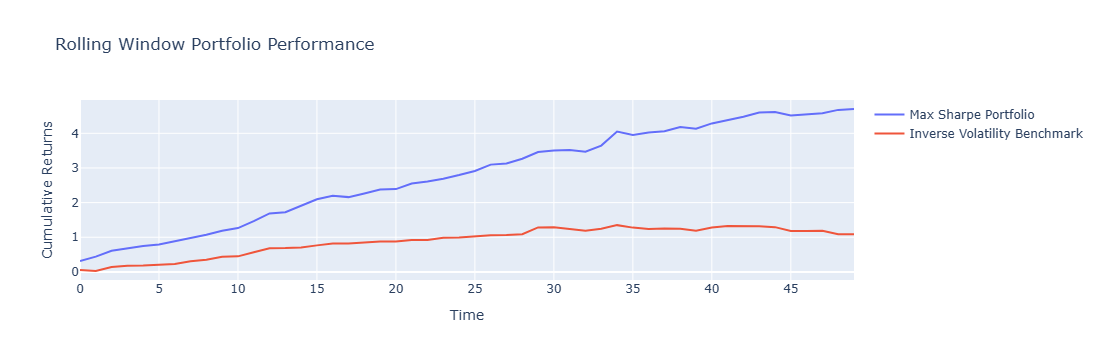

In [174]:
# Plot the cumulative returns for the rolling window strategy
fig = go.Figure()

# Aggregate cumulative returns for plotting
agg_cumulative_returns_model = np.sum([cr[0] for cr in cumulative_returns], axis=0)
agg_cumulative_returns_bench = np.sum([cr[1] for cr in cumulative_returns], axis=0)

# Add traces to the plot
fig.add_trace(go.Scatter(x=np.arange(len(agg_cumulative_returns_model)), y=agg_cumulative_returns_model, mode='lines', name='Max Sharpe Portfolio'))
fig.add_trace(go.Scatter(x=np.arange(len(agg_cumulative_returns_bench)), y=agg_cumulative_returns_bench, mode='lines', name='Inverse Volatility Benchmark'))

fig.update_layout(title="Rolling Window Portfolio Performance", xaxis_title="Time", yaxis_title="Cumulative Returns")
pio.show(fig)


In [108]:
# Calculate cumulative returns of SPY
cumulative_returns_spy = (1 + market_returns).cumprod() - 1

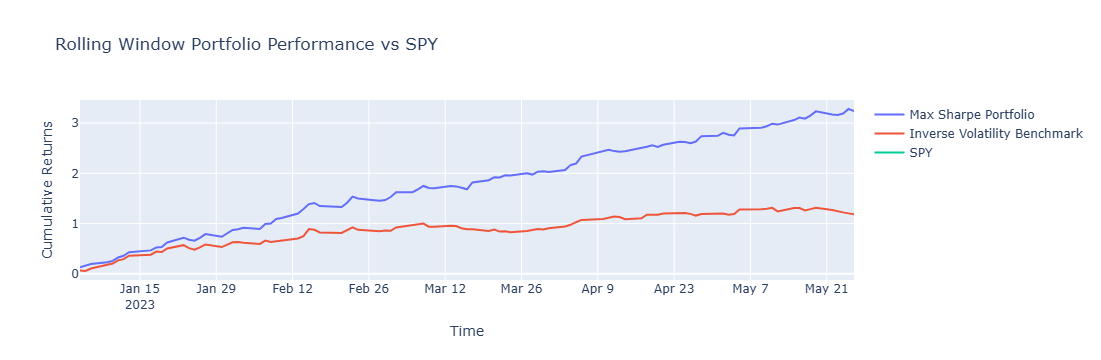

In [114]:
# Plot the cumulative returns for the rolling window strategy and SPY
fig = go.Figure()

# Aggregate cumulative returns for the rolling window portfolio and benchmark
agg_cumulative_returns_model = np.sum([cr[0] for cr in cumulative_returns], axis=0)
agg_cumulative_returns_bench = np.sum([cr[1] for cr in cumulative_returns], axis=0)

# Ensure that SPY cumulative returns are aligned with the rolling window dates
# Slice the SPY cumulative returns to match the time period of the rolling windows
spy_dates = returns.index[:len(agg_cumulative_returns_model)]  # Adjust the dates to match the rolling window length
cumulative_returns_spy_aligned = cumulative_returns_spy[:len(agg_cumulative_returns_model)]  # Align SPY's cumulative returns with rolling windows

# Add traces for portfolio performance
fig.add_trace(go.Scatter(x=spy_dates, y=agg_cumulative_returns_model, mode='lines', name='Max Sharpe Portfolio'))
fig.add_trace(go.Scatter(x=spy_dates, y=agg_cumulative_returns_bench, mode='lines', name='Inverse Volatility Benchmark'))

# Add trace for SPY cumulative returns
fig.add_trace(go.Scatter(x=spy_dates, y=cumulative_returns_spy_aligned, mode='lines', name='SPY'))

fig.update_layout(title="Rolling Window Portfolio Performance vs SPY", xaxis_title="Time", yaxis_title="Cumulative Returns")
pio.show(fig)


In [54]:
# 1. Create a Maximum Sharpe Ratio Portfolio
#model = MeanRisk( risk_measure=RiskMeasure.VARIANCE, objective_function=ObjectiveFunction.MAXIMIZE_RATIO, portfolio_params=dict(name="Max Sharpe"))
#model.fit(X_train)
#model_weights = model.weights_

In [56]:
#benchmark = InverseVolatility(portfolio_params=dict(name="Inverse Vol"))
#benchmark.fit(X_train)
#benchmark_weights = benchmark.weights_

In [58]:
pred_model = model.predict(X_test)
pred_bench = benchmark.predict(X_test)


In [60]:
print(pred_model.annualized_sharpe_ratio)
print(pred_bench.annualized_sharpe_ratio)

1.1768959324156039
0.8401740025146817


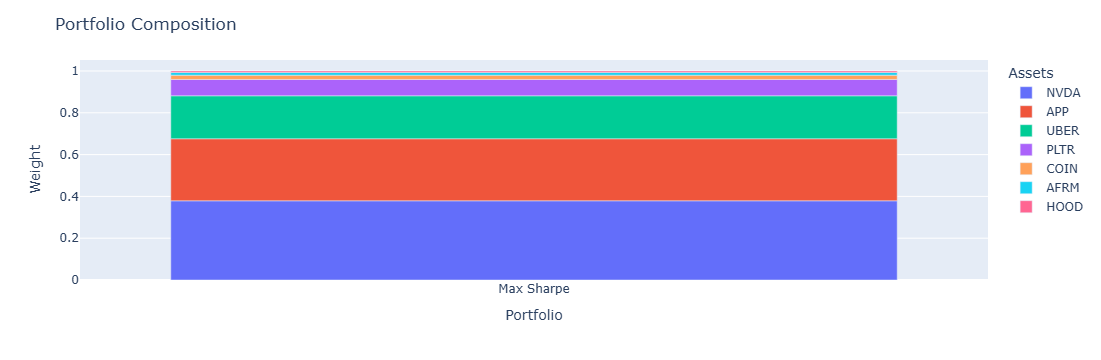

In [62]:
pred_model.plot_composition()

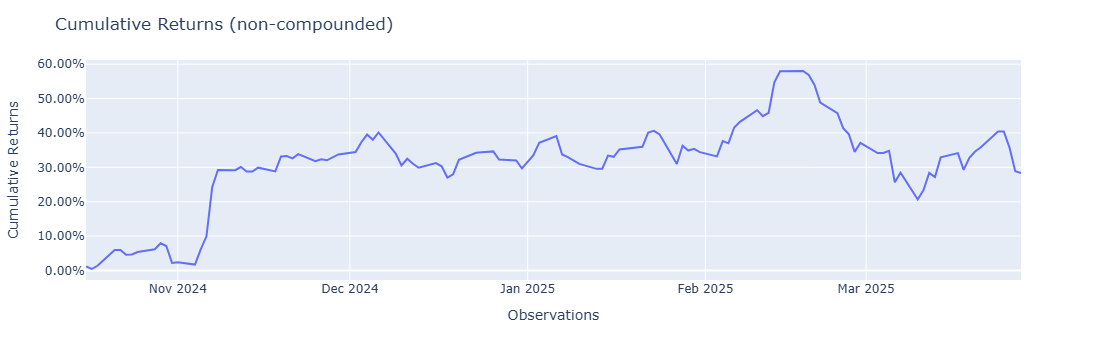

In [64]:
fig = pred_model.plot_cumulative_returns()
pio.show(fig)

In [66]:
print(pred_model.summary())

Mean                                               0.25%
Annualized Mean                                   63.72%
Variance                                           0.12%
Annualized Variance                               29.31%
Semi-Variance                                     0.057%
Annualized Semi-Variance                          14.49%
Standard Deviation                                 3.41%
Annualized Standard Deviation                     54.14%
Semi-Deviation                                     2.40%
Annualized Semi-Deviation                         38.06%
Mean Absolute Deviation                            2.46%
CVaR at 95%                                        7.43%
EVaR at 95%                                        8.14%
Worst Realization                                  9.13%
CDaR at 95%                                       32.62%
MAX Drawdown                                      37.35%
Average Drawdown                                   8.36%
EDaR at 95%                    

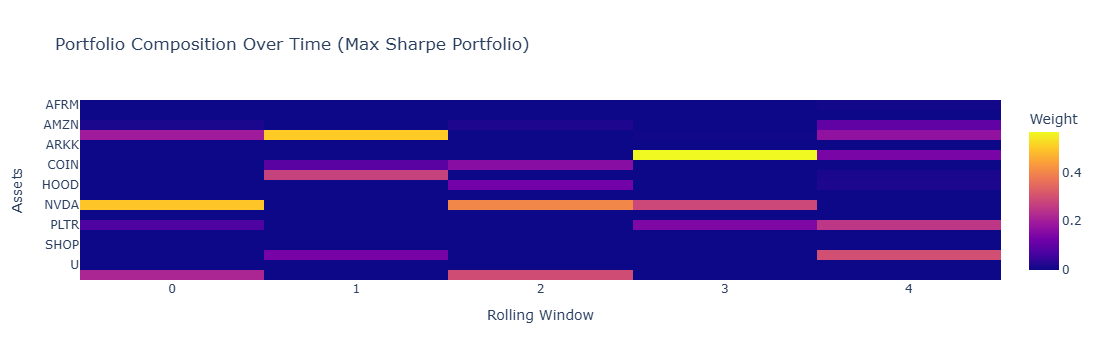

In [120]:
import plotly.express as px

# List to store portfolio weights for visualization
portfolio_weights_over_time = []

# Set the rolling window size (100 days)
window_size = 100

# Split the data into rolling windows and update the portfolio for each window
for train_data in rolling_window(returns, window_size):
    X_train = train_data

    # Create a Maximum Sharpe Ratio Portfolio
    model = MeanRisk(risk_measure=RiskMeasure.VARIANCE, objective_function=ObjectiveFunction.MAXIMIZE_RATIO, portfolio_params=dict(name="Max Sharpe"))
    model.fit(X_train)

    # Store portfolio weights for each rolling window (for visualization)
    portfolio_weights_over_time.append(model.weights_)

    # Create a benchmark portfolio (Inverse Volatility)
    benchmark = InverseVolatility(portfolio_params=dict(name="Inverse Vol"))
    benchmark.fit(X_train)

    # Predict the returns for the next period (test set)
    pred_model = model.predict(X_train)
    pred_bench = benchmark.predict(X_train)

# Convert portfolio weights to DataFrame for visualization
weights_df = pd.DataFrame(portfolio_weights_over_time, columns=returns.columns)

# Plot the portfolio composition over time
fig_weights = px.imshow(weights_df.T, labels=dict(x="Rolling Window", y="Assets", color="Weight"),
                        title="Portfolio Composition Over Time (Max Sharpe Portfolio)")
fig_weights.update_xaxes(showgrid=True)
fig_weights.update_yaxes(showgrid=True)
fig_weights.show()
